In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

def parse_rankings_data(excel_file_path, id_col, ranking_col, trendy_col):
    
    # Read the Excel file
    df = pd.read_excel(excel_file_path)
    
    # List to store expanded data
    expanded_data = []
    
    for idx, row in df.iterrows():
        id_val = row[id_col]
        rankings_str = str(row[ranking_col])
        categorical_val = row[trendy_col]
        
        # Parse rankings string using regex
        # Pattern matches: number (space optional) followed by count in parentheses
        pattern = r'(\d+)\s*\((\d+)\)'
        matches = re.findall(pattern, rankings_str)
        
        for ranking, count in matches:
            ranking = int(ranking)
            count = int(count)
            
            # Add each ranking value 'count' times to the data
            for _ in range(count):
                expanded_data.append({
                    'ID': id_val,
                    'Ranking': ranking,
                    'Category': categorical_val
                })
    
    # Create DataFrame
    result_df = pd.DataFrame(expanded_data)
    return result_df

    
def analyze_rankings(df):
    """Perform basic statistical analysis on the rankings data"""
    
    print("=== RANKINGS STATISTICS ===\n")
    
    # Overall statistics
    print("Overall Rankings Distribution:")
    print(df['Ranking'].value_counts().sort_index())
    print(f"\nTotal observations: {len(df)}")
    print(f"Mean ranking: {df['Ranking'].mean():.2f}")
    print(f"Median ranking: {df['Ranking'].median():.2f}")
    print(f"Standard deviation: {df['Ranking'].std():.2f}")
    
    # Statistics by Category
    print("\n=== BY CATEGORY STATISTICS ===")
    for category in sorted(df['Category'].unique()):
        cat_data = df[df['Category'] == category]['Ranking']
        print(f"\nCategory {category}:")
        print(f"  Count: {len(cat_data)}")
        print(f"  Mean: {cat_data.mean():.2f}")
        print(f"  Median: {cat_data.median():.2f}")
        print(f"  Std: {cat_data.std():.2f}")
        print(f"  Distribution: {dict(cat_data.value_counts().sort_index())}")
    
    # Statistics by ID
    print("\n=== BY ID STATISTICS ===")
    for id_val in sorted(df['ID'].unique()):
        id_data = df[df['ID'] == id_val]['Ranking']
        id_category = df[df['ID'] == id_val]['Category'].iloc[0]
        print(f"\nID {id_val} (Category: {id_category}):")
        print(f"  Count: {len(id_data)}")
        print(f"  Mean: {id_data.mean():.2f}")
        print(f"  Std: {id_data.std():.2f}")
        print(f"  Distribution: {dict(id_data.value_counts().sort_index())}")

def test_category_differences(df):
    """Test if rankings differ significantly by categorical variable"""
    
    print("\n" + "="*50)
    print("STATISTICAL TESTS FOR CATEGORY DIFFERENCES")
    print("="*50)
    
    # Separate data by category
    true_rankings = df[df['Category'] == True]['Ranking']
    false_rankings = df[df['Category'] == False]['Ranking']
    
    print(f"\nSample sizes:")
    print(f"  True: {len(true_rankings)}")
    print(f"  False: {len(false_rankings)}")
    
    if len(true_rankings) == 0 or len(false_rankings) == 0:
        print("Cannot perform tests - one category has no data")
        return
    
    # Descriptive statistics by group
    print(f"\nDescriptive Statistics:")
    print(f"True group:  Mean={true_rankings.mean():.3f}, Std={true_rankings.std():.3f}, Median={true_rankings.median():.3f}")
    print(f"False group: Mean={false_rankings.mean():.3f}, Std={false_rankings.std():.3f}, Median={false_rankings.median():.3f}")
    
    # 1. Mann-Whitney U test (non-parametric alternative to t-test)
    # Good for ordinal data like rankings
    try:
        statistic, p_value = stats.mannwhitneyu(true_rankings, false_rankings, alternative='two-sided')
        print(f"\n1. Mann-Whitney U Test:")
        print(f"   Statistic: {statistic:.3f}")
        print(f"   p-value: {p_value:.6f}")
        if p_value < 0.05:
            print("   Result: Significant difference between categories (p < 0.05)")
        else:
            print("   Result: No significant difference between categories (p >= 0.05)")
    except Exception as e:
        print(f"\n1. Mann-Whitney U Test: Error - {e}")
    
    # 2. Kolmogorov-Smirnov test (tests if distributions are different)
    try:
        ks_statistic, ks_p_value = stats.ks_2samp(true_rankings, false_rankings)
        print(f"\n2. Kolmogorov-Smirnov Test:")
        print(f"   Statistic: {ks_statistic:.3f}")
        print(f"   p-value: {ks_p_value:.6f}")
        if ks_p_value < 0.05:
            print("   Result: Distributions are significantly different (p < 0.05)")
        else:
            print("   Result: No significant difference in distributions (p >= 0.05)")
    except Exception as e:
        print(f"\n2. Kolmogorov-Smirnov Test: Error - {e}")
    
    # 3. Chi-square test for independence (categorical analysis)
    try:
        # Create contingency table
        contingency_table = pd.crosstab(df['Category'], df['Ranking'])
        print(f"\n3. Contingency Table:")
        print(contingency_table)
        
        chi2, chi2_p_value, dof, expected = stats.chi2_contingency(contingency_table)
        print(f"\n   Chi-square Test:")
        print(f"   Chi2 statistic: {chi2:.3f}")
        print(f"   p-value: {chi2_p_value:.6f}")
        print(f"   Degrees of freedom: {dof}")
        if chi2_p_value < 0.05:
            print("   Result: Category and ranking are significantly associated (p < 0.05)")
        else:
            print("   Result: No significant association between category and ranking (p >= 0.05)")
    except Exception as e:
        print(f"\n3. Chi-square Test: Error - {e}")
    
    # 4. Effect size (Cohen's d for means difference)
    try:
        pooled_std = np.sqrt(((len(true_rankings) - 1) * true_rankings.std()**2 + 
                             (len(false_rankings) - 1) * false_rankings.std()**2) / 
                            (len(true_rankings) + len(false_rankings) - 2))
        cohens_d = (true_rankings.mean() - false_rankings.mean()) / pooled_std
        print(f"\n4. Effect Size (Cohen's d): {cohens_d:.3f}")
        if abs(cohens_d) < 0.2:
            effect_size = "negligible"
        elif abs(cohens_d) < 0.5:
            effect_size = "small"
        elif abs(cohens_d) < 0.8:
            effect_size = "medium"
        else:
            effect_size = "large"
        print(f"   Interpretation: {effect_size} effect size")
    except Exception as e:
        print(f"\n4. Effect Size: Error - {e}")
    
    return {
        'true_rankings': true_rankings,
        'false_rankings': false_rankings,
        'contingency_table': contingency_table if 'contingency_table' in locals() else None
    }

    

=== RANKINGS STATISTICS ===

Overall Rankings Distribution:
Ranking
0    12
1    74
2    84
3    70
Name: count, dtype: int64

Total observations: 240
Mean ranking: 1.88
Median ranking: 2.00
Standard deviation: 0.89

=== BY CATEGORY STATISTICS ===

Category 0.0:
  Count: 120
  Mean: 1.76
  Median: 2.00
  Std: 0.84
  Distribution: {0: 6, 1: 42, 2: 47, 3: 25}

Category 1.0:
  Count: 120
  Mean: 2.01
  Median: 2.00
  Std: 0.92
  Distribution: {0: 6, 1: 32, 2: 37, 3: 45}

=== BY ID STATISTICS ===

ID 1.0 (Category: 1.0):
  Count: 12
  Mean: 2.50
  Std: 0.67
  Distribution: {1: 1, 2: 4, 3: 7}

ID 19.0 (Category: 1.0):
  Count: 12
  Mean: 2.42
  Std: 0.67
  Distribution: {1: 1, 2: 5, 3: 6}

ID 21.0 (Category: 1.0):
  Count: 12
  Mean: 2.67
  Std: 0.49
  Distribution: {2: 4, 3: 8}

ID 30.0 (Category: 0.0):
  Count: 12
  Mean: 2.08
  Std: 1.00
  Distribution: {0: 1, 1: 2, 2: 4, 3: 5}

ID 45.0 (Category: 0.0):
  Count: 12
  Mean: 2.08
  Std: 0.67
  Distribution: {1: 2, 2: 7, 3: 3}

ID 61.0 (Cat

/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_49370/2708917247.py:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Not trendy', 'Trendy'])
/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_49370/2708917247.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['not trendy', 'trendy'])
/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_49370/2708917247.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['not trendy', 'trendy'])


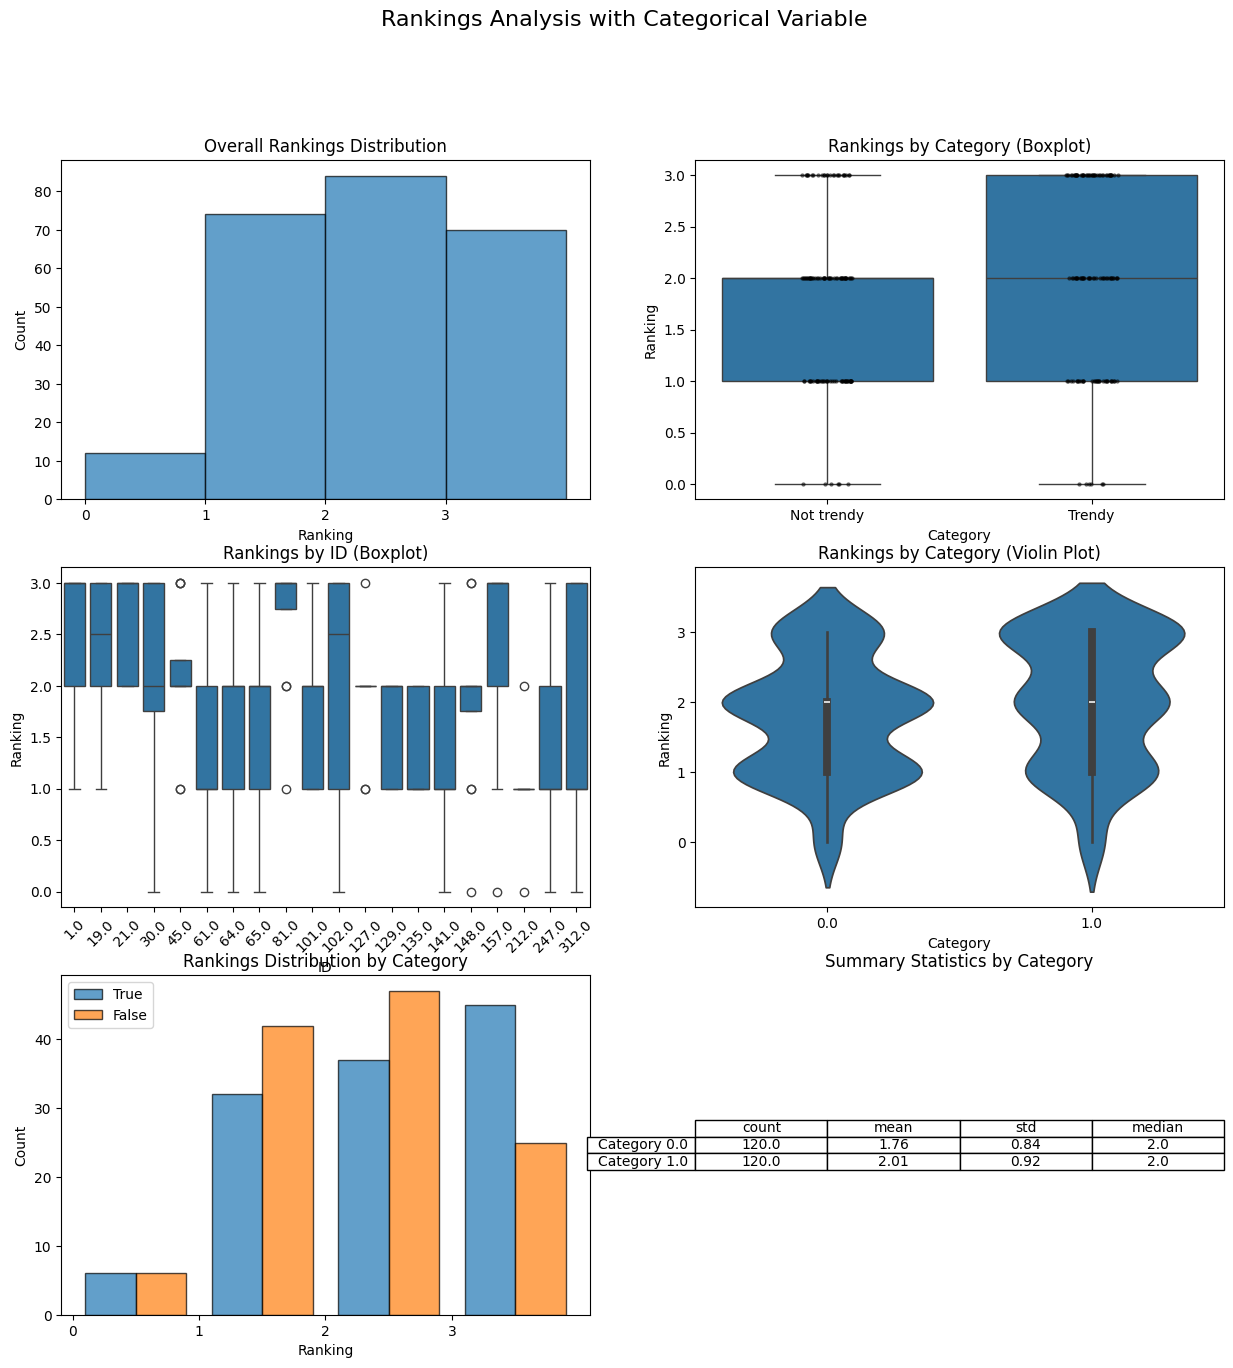

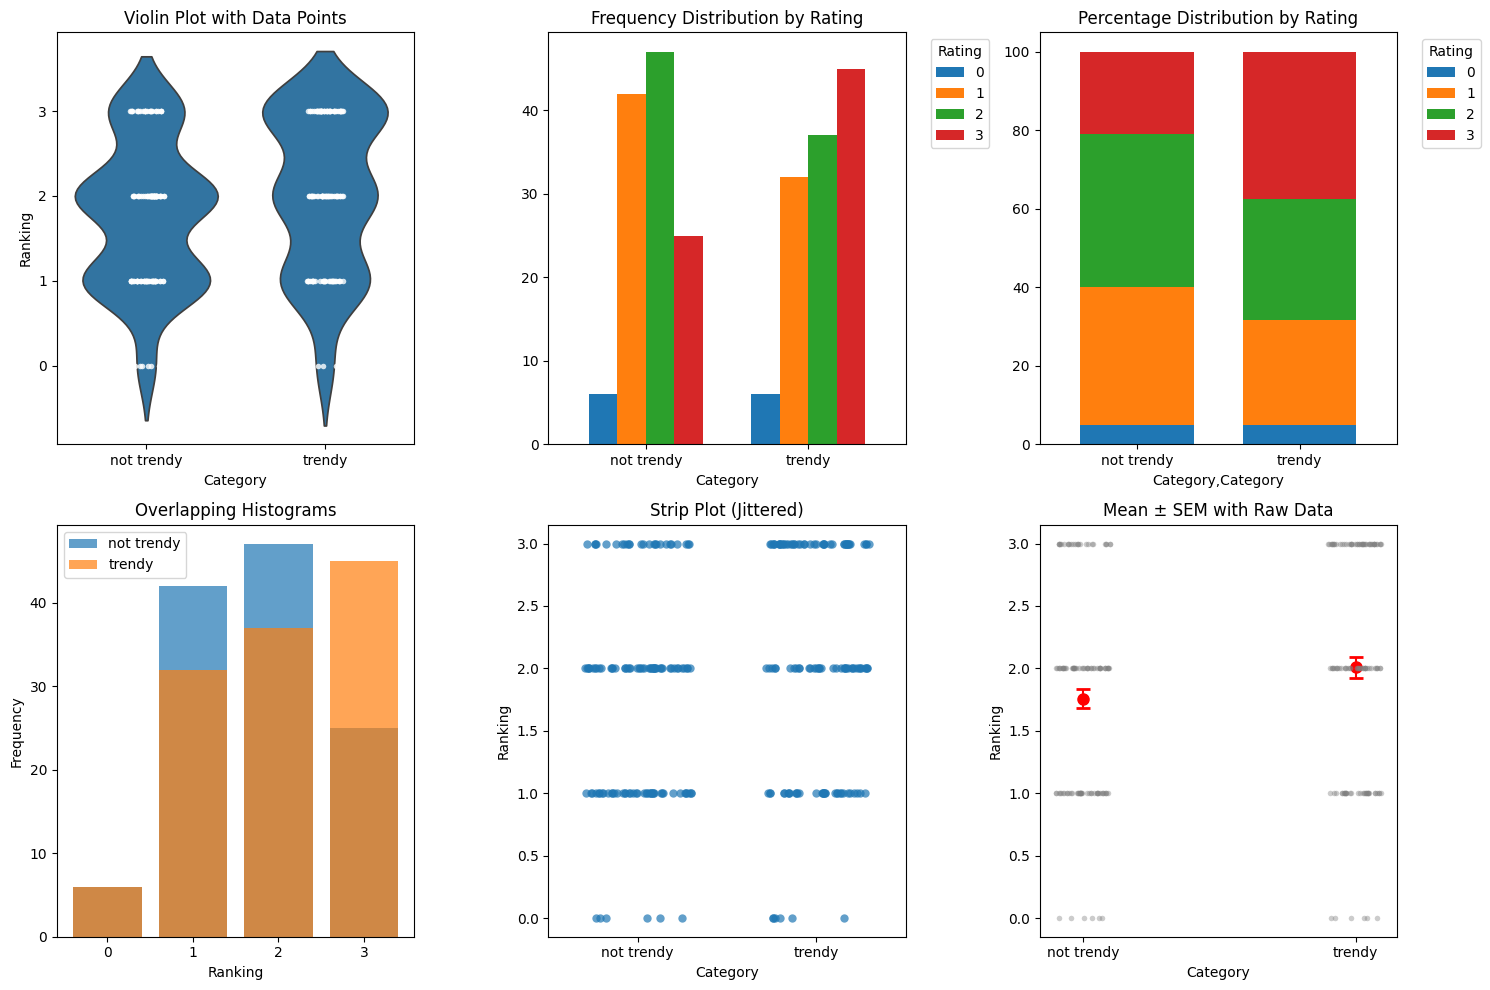


Processed data saved to 'expanded_rankings_data.csv'

Categorical breakdown:
Category
0.0    120
1.0    120
Name: count, dtype: int64

Mean ranking by category:
Category
0.0    1.758333
1.0    2.008333
Name: Ranking, dtype: float64


In [20]:
# Perform analysis
analyze_rankings(df)

# Test for category differences
test_results = test_category_differences(df)

# Create visualizations
create_visualizations(df)

# Save the processed data
df.to_csv('evaluation/expanded_rankings_data.csv', index=False)
print(f"\nProcessed data saved to 'expanded_rankings_data.csv'")

# Additional categorical analysis
print(f"\nCategorical breakdown:")
print(df['Category'].value_counts())
print(f"\nMean ranking by category:")
print(df.groupby('Category')['Ranking'].mean())


In [3]:
df = parse_rankings_data('evaluation/evaluation-results.xlsx', id_col=1, ranking_col=2, trendy_col=4 )

print(df.head(20))
print(f"\nTotal rows: {len(df)}")


      ID  Ranking  Category
0   61.0        0       0.0
1   61.0        1       0.0
2   61.0        1       0.0
3   61.0        1       0.0
4   61.0        1       0.0
5   61.0        1       0.0
6   61.0        1       0.0
7   61.0        2       0.0
8   61.0        2       0.0
9   61.0        2       0.0
10  61.0        3       0.0
11  61.0        3       0.0
12  19.0        1       1.0
13  19.0        2       1.0
14  19.0        2       1.0
15  19.0        2       1.0
16  19.0        2       1.0
17  19.0        2       1.0
18  19.0        3       1.0
19  19.0        3       1.0

Total rows: 240


/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_80300/114020679.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  id_val = row[id_col]
/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_80300/114020679.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rankings_str = str(row[ranking_col])
/var/folders/wr/4fyz19y54_3_8gp5lh28w05xl0jvvw/T/ipykernel_80300/114020679.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

In [74]:

def create_visualizations(df):
    
    #fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), gridspec_kw={'width_ratios': [3, 3, 3, 2]})
    #fig.suptitle('Rankings Analysis', fontsize=16)

    # Use these colours: colours = blue = trendy, red = popular, orange = neither popular nor trending, green = other
    
    # Histogram/bar plot showing frequency distribution
    df_counts = df.groupby(['Category', 'Ranking']).size().unstack(fill_value=0)
    df_counts.plot(kind='bar', ax=axes[0], width=0.7,color=['green', 'orange', 'red', 'blue'])
    axes[0].set_title('Frequency Distribution by Rating')
    axes[0].set_xticklabels(['not trendy', 'trendy'], rotation=0)
    axes[0].legend(['Other', 'Neither popular nor trendy', 'Popular but not trendy', 'Trendy'], 
               title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left').set_visible(False)
    #axes[0].get_legend().remove()
    
    # Stacked percentage bar chart
    df_pct = df.groupby(['Category', 'Ranking']).size().groupby('Category').apply(
        lambda x: x / x.sum() * 100).unstack(fill_value=0)
    df_pct.plot(kind='bar', stacked=True, ax=axes[1], width=0.7,color=['green', 'orange', 'red', 'blue'])
    axes[1].set_title('Percentage Distribution by Rating')
    axes[1].set_xticklabels(['not trendy', 'trendy'], rotation=0)
    axes[1].set_xlabel('Category')
    axes[1].legend(['Other', 'Neither popular nor trendy', 'Popular but not trendy', 'Trendy'], 
               title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left').set_visible(False)
    #axes[1].get_legend().remove()
    
    # Side-by-side histograms
    for i, category in enumerate(df['Category'].unique()):
        subset = df[df['Category'] == category]['Ranking']
        label = 'not trendy' if i == 0 else 'trendy'
        axes[2].hist(subset, alpha=0.5, label=label, bins=range(int(df['Ranking'].min()), 
                       int(df['Ranking'].max()) + 2), align='left', rwidth=0.8,color=['orange','blue'][i])
    axes[2].set_title('Overlapping Histograms')
    axes[2].set_xlabel('Rating')
    axes[2].set_xticks([0,1,2,3])
    axes[2].set_xticklabels(['Other','Neither','Popular','Trendy'])
    axes[2].set_ylabel('Frequency')
    axes[2].legend().set_visible(False)

    axes[3].axis('off')  # Hide the axis
    handles1, labels1 = axes[0].get_legend_handles_labels()
    legend1 = axes[3].legend(handles1,['Other', 'Neither popular nor trendy', 'Popular but not trendy', 'Trendy'], title='Rating', 
                         loc='upper left',bbox_to_anchor=(0, 1))
    axes[3].add_artist(legend1)
    handles2, labels2 = axes[2].get_legend_handles_labels()
    legend2 = axes[3].legend(handles2,labels2, title='Prediction', loc='center left',bbox_to_anchor=(0, 0.3))
    
    plt.tight_layout()
    plt.savefig('output/figs/evaluationresult.svg',bbox_inches='tight')
    plt.show()

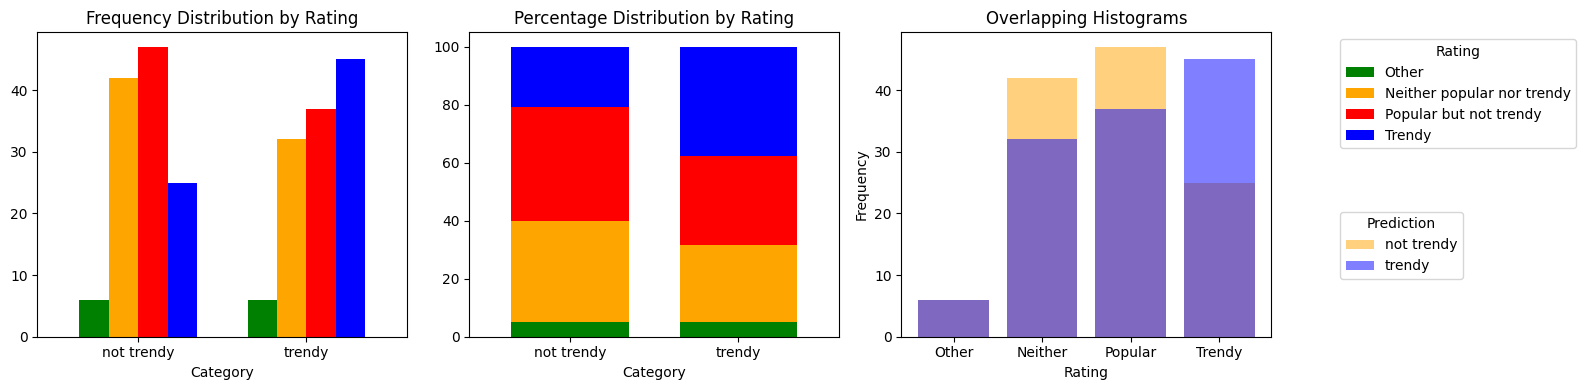

In [75]:
# Create visualizations
create_visualizations(df)

In [67]:
import pandas as pd

df_genquests = pd.read_csv('output/generated_questions.csv')
df_genquests.head()

,Topic Name,Baseline Zero-Shot Generation Approach,Our Topic-Augmented Generation Approach
0,Ketamine for treatment-resistant depression,1. What is the comparative effectiveness ...,1. How do neurophysiological biomarkers (...
1,Ketamine for treatment-resistant depression,2. Among patients with treatment-resistan...,2. What is the mechanistic basis for the ...
2,Ketamine for treatment-resistant depression,3. How do psychosocial interventions (e.g...,3. Can co-administration of dopamine modu...
3,Ketamine for treatment-resistant depression,"4. What is the role of inflammatory, meta...","4. To what extent do ethnic, metabolic (e..."
4,Ketamine for treatment-resistant depression,5. How do real-world treatment sequences ...,5. Is nasal epithelial integrity critical...


In [70]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

def calculate_perplexity(text):
    model = GPT2LMHeadModel.from_pretrained('gpt2')
    tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
    
    # Encode and calculate loss
    encodings = tokenizer(text, return_tensors='pt')
    max_length = model.config.n_positions
    stride = 512
    
    nlls = []
    for i in range(0, encodings.input_ids.size(1), stride):
        begin_loc = max(i + stride - max_length, 0)
        end_loc = min(i + stride, encodings.input_ids.size(1))
        trg_len = end_loc - i
        
        input_ids = encodings.input_ids[:, begin_loc:end_loc]
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100
        
        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss * trg_len
        
        nlls.append(neg_log_likelihood)
    
    perplexity = torch.exp(torch.stack(nlls).sum() / end_loc)
    return perplexity.item()

# Usage
question = "What are the specific molecular mechanisms by which CRISPR-Cas9 induces off-target effects?"
print(f"Perplexity: {calculate_perplexity(question)}")



Perplexity: 17.612672805786133


In [71]:
baseline = []
experimental = []
for question in df_genquests["Baseline Zero-Shot Generation Approach"]:
    p = calculate_perplexity(question)
    print(f"Baseline Perplexity: {p}")
    baseline.append(p)
for question in df_genquests["Our Topic-Augmented Generation Approach"]:
    p = calculate_perplexity(question)
    print(f"Experimental Perplexity: {p}")
    experimental.append(p)

df_genquests['BaselinePerplexity']=baseline
df_genquests['ExperimentalPerplexity']=experimental

Baseline Perplexity: 21.59363555908203
Baseline Perplexity: 18.2342586517334
Baseline Perplexity: 28.147354125976562
Baseline Perplexity: 50.035552978515625
Baseline Perplexity: 91.38626861572266
Baseline Perplexity: 13.279261589050293
Baseline Perplexity: 42.76475143432617
Baseline Perplexity: 35.95405197143555
Baseline Perplexity: 15.561840057373047
Baseline Perplexity: 36.57902908325195
Baseline Perplexity: 33.945770263671875
Baseline Perplexity: 42.79833984375
Baseline Perplexity: 24.908597946166992
Baseline Perplexity: 56.00768280029297
Baseline Perplexity: 38.022274017333984
Baseline Perplexity: 20.774776458740234
Baseline Perplexity: 31.373165130615234
Baseline Perplexity: 60.94114685058594
Baseline Perplexity: 58.19538497924805
Baseline Perplexity: 71.55792999267578
Baseline Perplexity: 69.60208129882812
Baseline Perplexity: 49.84515380859375
Baseline Perplexity: 21.804224014282227
Baseline Perplexity: 41.44822692871094
Baseline Perplexity: 58.45233154296875
Baseline Perplexity

In [72]:
! pip install lexicalrichness

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 12.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.6 MB/s eta 0:00:00
  Created wheel for lexicalrichness: filename=lexicalrichness-0.5.1-py3-none-any.whl size=15416 sha256=0fadcdfd7255bffb7fce18ff4d31f627ee0ba7dffc041f08800682d433ec5a79
  Stored in directory: /Users/hastingj/Library/Caches/pip/wheels/eb/40/d0/053edb84485f223effdbf0f91fc2b6ec6fc6cf2230aadca09a
Successfully built lexicalrichness
  Attempting uninstall: nltk
    Found existing installation: nltk 3.8.1
    Uninstalling nltk-3.8.1:
      Successfully uninstalled nltk-3.8.1


In [78]:
from lexicalrichness import LexicalRichness

def calculate_lexical_diversity(text):
    lex = LexicalRichness(text)
    
    metrics = {
        'ttr': lex.ttr,  # Type-Token Ratio
        'rttr': lex.rttr,  # Root TTR
        'cttr': lex.cttr,  # Corrected TTR
        'mtld': lex.mtld()  # Measure of Textual Lexical Diversity
    }
    
    return metrics

# Install first: pip install lexicalrichness
question = "What are the specific implications of quantum entanglement for cryptographic security?"
metrics = calculate_lexical_diversity(question)
print(f"Lexical Diversity Metrics: {metrics}")
question = "What are the specific implications of available therapy for mental health?"
metrics = calculate_lexical_diversity(question)
print(f"Lexical Diversity Metrics: {metrics}")
question = "What are the implications of quantum entanglement for  security?"
metrics = calculate_lexical_diversity(question)
print(f"Lexical Diversity Metrics: {metrics}")


Lexical Diversity Metrics: {'ttr': 1.0, 'rttr': 3.3166247903554, 'cttr': 2.345207879911715, 'mtld': 11.0}
Lexical Diversity Metrics: {'ttr': 1.0, 'rttr': 3.3166247903554, 'cttr': 2.345207879911715, 'mtld': 11.0}
Lexical Diversity Metrics: {'ttr': 1.0, 'rttr': 3.0, 'cttr': 2.121320343559643, 'mtld': 9.0}


In [79]:
baseline = []
experimental = []
for question in df_genquests["Baseline Zero-Shot Generation Approach"]:
    p = calculate_lexical_diversity(question)['cttr']
    print(f"Baseline Lexical Diversity: {p}")
    baseline.append(p)
for question in df_genquests["Our Topic-Augmented Generation Approach"]:
    p = calculate_lexical_diversity(question)['cttr']
    print(f"Experimental Lexical Diversity: {p}")
    experimental.append(p)

df_genquests['BaselineLexicalDiversity']=baseline
df_genquests['ExperimentalLexicalDiversity']=experimental

Baseline Lexical Diversity: 3.8890872965260117
Baseline Lexical Diversity: 4.4351113589128115
Baseline Lexical Diversity: 3.8805700005813275
Baseline Lexical Diversity: 3.6927447293799815
Baseline Lexical Diversity: 3.70520868893662
Baseline Lexical Diversity: 3.569653238400649
Baseline Lexical Diversity: 3.6080267658177294
Baseline Lexical Diversity: 3.466876226407682
Baseline Lexical Diversity: 3.7416573867739413
Baseline Lexical Diversity: 3.3407655239053047
Baseline Lexical Diversity: 3.6830036830055244
Baseline Lexical Diversity: 3.807886552931954
Baseline Lexical Diversity: 3.25
Baseline Lexical Diversity: 3.5355339059327373
Baseline Lexical Diversity: 3.7416573867739413
Baseline Lexical Diversity: 3.6055512754639896
Baseline Lexical Diversity: 3.391164991562634
Baseline Lexical Diversity: 3.1754264805429417
Baseline Lexical Diversity: 3.165869118066518
Baseline Lexical Diversity: 3.6080267658177294
Baseline Lexical Diversity: 3.086066999241838
Baseline Lexical Diversity: 3.87298

In [80]:
df_genquests.head()

,Topic Name,Baseline Zero-Shot Generation Approach,Our Topic-Augmented Generation Approach,BaselinePerplexity,ExperimentalPerplexity,BaselineLexicalDiversity,ExperimentalLexicalDiversity
0,Ketamine for treatment-resistant depression,1. What is the comparative effectiveness ...,1. How do neurophysiological biomarkers (...,21.593636,54.812912,3.889087,4.129483
1,Ketamine for treatment-resistant depression,2. Among patients with treatment-resistan...,2. What is the mechanistic basis for the ...,18.234259,19.443111,4.435111,3.836172
2,Ketamine for treatment-resistant depression,3. How do psychosocial interventions (e.g...,3. Can co-administration of dopamine modu...,28.147354,46.671211,3.880570,3.872983
3,Ketamine for treatment-resistant depression,"4. What is the role of inflammatory, meta...","4. To what extent do ethnic, metabolic (e...",50.035553,28.950706,3.692745,3.913119
4,Ketamine for treatment-resistant depression,5. How do real-world treatment sequences ...,5. Is nasal epithelial integrity critical...,91.386269,53.162823,3.705209,3.625000


In [41]:
import nltk
nltk.download('wordnet_ic')
nltk.download('genesis')

[nltk_data] Downloading package wordnet_ic to
[nltk_data]     /Users/hastingj/nltk_data...
[nltk_data]   Unzipping corpora/wordnet_ic.zip.
[nltk_data] Downloading package genesis to
[nltk_data]     /Users/hastingj/nltk_data...
[nltk_data]   Unzipping corpora/genesis.zip.


True

In [43]:
import nltk
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import numpy as np

# Download required NLTK data (run once)
# nltk.download('wordnet')
# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')

def get_wordnet_pos(treebank_tag):
    """Convert treebank POS tags to WordNet POS tags"""
    if treebank_tag.startswith('J'):
        return wn.ADJ
    elif treebank_tag.startswith('V'):
        return wn.VERB
    elif treebank_tag.startswith('N'):
        return wn.NOUN
    elif treebank_tag.startswith('R'):
        return wn.ADV
    else:
        return None

def get_max_depth(word, pos=None):
    """Get the maximum depth of a word in WordNet hierarchy"""
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return 0
    
    max_depth = 0
    for synset in synsets:
        depth = synset.max_depth()
        if depth > max_depth:
            max_depth = depth
    
    return max_depth

def calculate_semantic_specificity(text, use_pos_tags=True):
    """
    Calculate semantic specificity based on WordNet hierarchy depth
    
    Args:
        text: Input text (question)
        use_pos_tags: Whether to use POS tagging for better accuracy
    
    Returns:
        dict with average depth, max depth, and specificity score
    """
    # Tokenize and get POS tags
    tokens = word_tokenize(text.lower())
    
    if use_pos_tags:
        pos_tags = nltk.pos_tag(tokens)
    else:
        pos_tags = [(token, None) for token in tokens]
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    
    depths = []
    word_details = []
    
    for word, pos_tag in pos_tags:
        # Skip stopwords, punctuation, and very short words
        if word in stop_words or not word.isalpha() or len(word) < 3:
            continue
        
        # Convert POS tag to WordNet format
        wn_pos = get_wordnet_pos(pos_tag) if use_pos_tags else None
        
        # Get depth
        depth = get_max_depth(word, pos=wn_pos)
        
        if depth > 0:  # Only include words found in WordNet
            depths.append(depth)
            word_details.append({
                'word': word,
                'pos': wn_pos,
                'depth': depth
            })
    
    if not depths:
        return {
            'avg_depth': 0,
            'max_depth': 0,
            'min_depth': 0,
            'specificity_score': 0,
            'word_count': 0,
            'word_details': []
        }
    
    return {
        'avg_depth': np.mean(depths),
        'max_depth': np.max(depths),
        'min_depth': np.min(depths),
        'specificity_score': np.mean(depths)/(1/len(depths)), #np.mean(depths),  # Primary metric
        'word_count': len(depths),
        'word_details': word_details
    }

# Example usage
questions = [
    "What is a thing?",  # Very vague
    "What are some animals?",  # Somewhat vague
    "What are the specific molecular mechanisms of CRISPR-Cas9?",  # Very specific
    "How does a golden retriever's temperament differ from a labrador?"  # Specific
]

print("Semantic Specificity Analysis\n" + "="*60)
for question in questions:
    result = calculate_semantic_specificity(question)
    print(f"\nQuestion: {question}")
    print(f"  Specificity Score: {result['specificity_score']:.2f}")
    print(f"  Avg Depth: {result['avg_depth']:.2f}")
    print(f"  Max Depth: {result['max_depth']}")
    print(f"  Words analyzed: {result['word_count']}")
    print(f"  Top specific words: {[w['word'] + f'({w['depth']})' for w in sorted(result['word_details'], key=lambda x: x['depth'], reverse=True)[:3]]}")
    




    

Semantic Specificity Analysis

Question: What is a thing?
  Specificity Score: 10.00
  Avg Depth: 10.00
  Max Depth: 10
  Words analyzed: 1
  Top specific words: ['thing(10)']

Question: What are some animals?
  Specificity Score: 6.00
  Avg Depth: 6.00
  Max Depth: 6
  Words analyzed: 1
  Top specific words: ['animals(6)']

Question: What are the specific molecular mechanisms of CRISPR-Cas9?
  Specificity Score: 8.00
  Avg Depth: 8.00
  Max Depth: 8
  Words analyzed: 1
  Top specific words: ['mechanisms(8)']

Question: How does a golden retriever's temperament differ from a labrador?
  Specificity Score: 30.00
  Avg Depth: 10.00
  Max Depth: 16
  Words analyzed: 3
  Top specific words: ['retriever(16)', 'temperament(8)', 'labrador(6)']


In [102]:
from nltk.corpus import wordnet_ic
from nltk.corpus import genesis
from nltk.corpus.reader.wordnet import information_content

# Download IC corpus
# nltk.download('wordnet_ic')
# nltk.download('genesis')

def calculate_information_content_specificity(text):
    """
    Use Information Content from a corpus
    Higher IC = more specific concept
    """
    # Load IC from Brown corpus (you can use others)
    brown_ic = wordnet_ic.ic('ic-brown.dat')
    semcor_ic = wordnet_ic.ic('ic-semcor.dat')
    
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    
    ic_scores = []
    
    for token in tokens:
        word = token.lower()
        if word in stop_words or not word.isalpha():
            continue
        
        synsets = wn.synsets(word, pos=wn.NOUN)  # Focus on nouns
        if synsets:
            # Get IC for each synset
            for synset in synsets:
                ic = information_content(synset, brown_ic)
                if ic > 20:
                    ic = 20 # Ceiling for WordNet scores
                if ic > 0:
                    ic_scores.append(ic)
        else: 
            # No synsets - use heuristics
            if (len(word) > 9 or  # Long words
                token.isupper() or  # Acronyms like "CRISPR"
                '-' in word or  # Hyphenated terms
                any(c.isdigit() for c in word)):  # Contains numbers
                    score = 30  # Something higher than WordNet ceiling to reflect scientific content
                    ic_scores.append(score)
            else: 
                score = 5
                ic_scores.append(score)
    
    return np.mean(ic_scores) if ic_scores else 0

# Test
print(f"Thing: {calculate_information_content_specificity('thing'):.2f}")
print(f"CRISPR: {calculate_information_content_specificity('CRISPR'):.2f}")

Thing: 7.51
CRISPR: 30.00


In [103]:
baseline = []
experimental = []
for question in df_genquests["Baseline Zero-Shot Generation Approach"]:
    p = calculate_information_content_specificity(question)
    print(f"Baseline IC Specificity: {p}")
    baseline.append(p)
for question in df_genquests["Our Topic-Augmented Generation Approach"]:
    p = calculate_information_content_specificity(question)
    print(f"Experimental IC Specificity: {p}")
    experimental.append(p)

df_genquests['BaselineICSpecificity']=baseline
df_genquests['ExperimentalICSpecificity']=experimental

Baseline IC Specificity: 12.631994764960082
Baseline IC Specificity: 9.595273617972797
Baseline IC Specificity: 11.63942945283293
Baseline IC Specificity: 10.561047976148627
Baseline IC Specificity: 9.56336532690047
Baseline IC Specificity: 10.194134861680388
Baseline IC Specificity: 9.56397033456557
Baseline IC Specificity: 9.936343861994857
Baseline IC Specificity: 10.970463849104268
Baseline IC Specificity: 10.039002754066459
Baseline IC Specificity: 9.566592086950912
Baseline IC Specificity: 9.617987755006462
Baseline IC Specificity: 8.915085021811208
Baseline IC Specificity: 9.653690247581855
Baseline IC Specificity: 9.372699846394344
Baseline IC Specificity: 10.207778439946294
Baseline IC Specificity: 8.706344648485127
Baseline IC Specificity: 8.787201299808157
Baseline IC Specificity: 8.050001246099315
Baseline IC Specificity: 9.839253436328374
Baseline IC Specificity: 9.422582428542471
Baseline IC Specificity: 9.209501697101084
Baseline IC Specificity: 8.544867521463955
Baselin

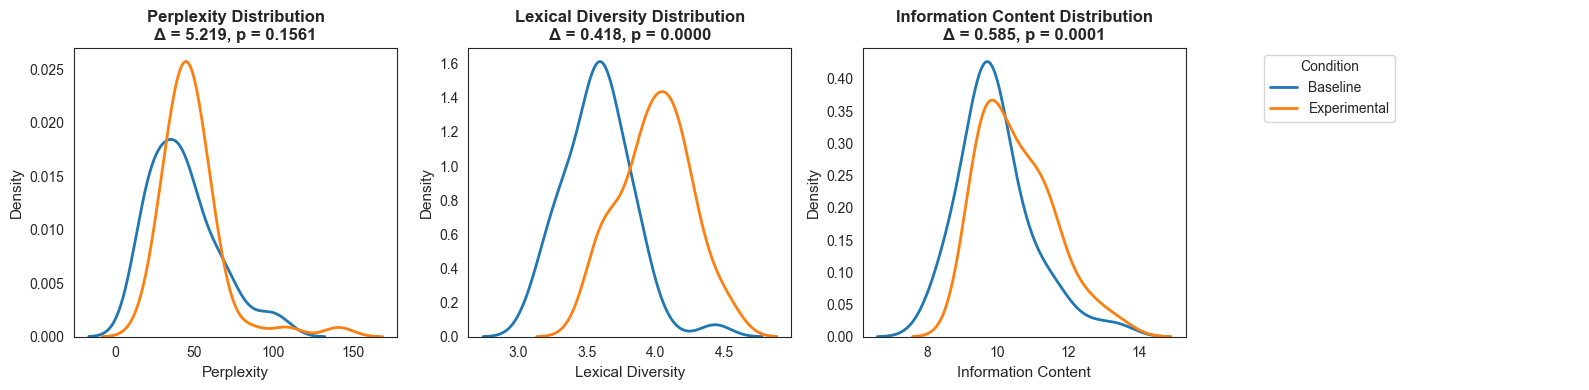

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

metrics = [
    ('Perplexity', 'BaselinePerplexity', 'ExperimentalPerplexity'),
    ('Lexical Diversity', 'BaselineLexicalDiversity', 'ExperimentalLexicalDiversity'),
    ('Information Content', 'BaselineICSpecificity', 'ExperimentalICSpecificity'),
]

for idx, (title, baseline_col, exp_col) in enumerate(metrics):
    # Create density plots
    sns.kdeplot(data=df_genquests[baseline_col], 
                label='Baseline', linewidth=2, ax=axes[idx], color='#1f77b4')
    sns.kdeplot(data=df_genquests[exp_col], 
                label='Experimental', linewidth=2, ax=axes[idx], color='#ff7f0e')
    
    # Calculate statistics
    baseline_mean = df_genquests[baseline_col].mean()
    exp_mean = df_genquests[exp_col].mean()
    t_stat, p_value = stats.ttest_rel(df_genquests[baseline_col], 
                                       df_genquests[exp_col])
    
    # Add title with statistics
    axes[idx].set_title(f'{title} Distribution\n' + 
                       f'Δ = {exp_mean - baseline_mean:.3f}, p = {p_value:.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(title, fontsize=11)
    axes[idx].set_ylabel('Density', fontsize=11)
    axes[idx].legend(fontsize=10).set_visible(False)

axes[len(metrics)].axis('off')  # Hide the axis
handles, labels = axes[0].get_legend_handles_labels()
axes[len(metrics)].legend(handles,labels, title='Condition', 
                         loc='upper left',bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.savefig('output/figs/genquestspecificity.svg',bbox_inches='tight')
plt.show()